In [1]:
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

# import os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'


# This is required to run multiple processes with JAX.
from multiprocessing import set_start_method
set_start_method('forkserver', force=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from tqdm import tqdm
from pathlib import Path

# print(jax.devices())
# jax.config.update("jax_debug_nans", True)

from config import Config
import data

In [3]:
cfg = Config.from_file("/nas/cee-water/cjgleason/ted/swot-ml/runs/mississippi/swot.yml")

In [14]:
cfg.quiet = False
mgr = data.DynamicCacheManager(cfg)
cache_dir = mgr.create_cache('train')

Caches will be stored at: /scratch4/workspace/tlanghorst_umass_edu-swot-ml-zarr/zbs_batched/_cache4/7c4f922b1edbd637
Calculating training statistics for encoding and normalization...
✅ All caches created and indexed.


In [15]:
dataset = data.CachedBasinGraphDataset(cfg, cache_dir, 'train')

Calculating training statistics for encoding and normalization...
Loading static attributes...Done!
Loading basin graphs...Done!
Loading optimized indices for train...Done!


In [16]:
len(dataset.subbasins)

1390

In [17]:
basin, date, batch = dataset[0]

In [18]:
np.sum(~np.isnan(batch.y['discharge'][-1,:,0]))

1284

In [12]:
cfg.num_workers = 8
dataloader = data.CachedBasinGraphDataLoader(cfg, dataset)

Dataloader using 8 parallel CPU worker(s).


In [13]:
%%memit

count = 0
for basin, date, batch in tqdm(dataloader):
    count += 1
    if count == 40:
        break
print(len(basin))

  0%|          | 39/1000000000000 [05:34<2381419788:59:06,  8.57s/it]

273
peak memory: 6552.89 MiB, increment: 1492.94 MiB


In [10]:
import train
cfg.log = False
trainer = train.Trainer(cfg, dataloader)
trainer.start_training()

# type(trainer.model)

Model contains 1,226,957 parameters
2025-12-03 15:20:49,598 - INFO - ~~~ Starting training (max_steps=50000, max_hours=48) ~~~


Training Steps:   0%|          | 14/50000 [20:53<1243:12:10, 89.54s/it]

KeyboardInterrupt


KeyboardInterrupt



In [10]:
for basin, date, batch in dataloader:
    break

    

In [11]:
model = trainer.model
key = jax.random.PRNGKey(0)

y_hat = model(batch, key)

In [12]:
y_hat['discharge']['mu'].shape

(90, 7000, 100)

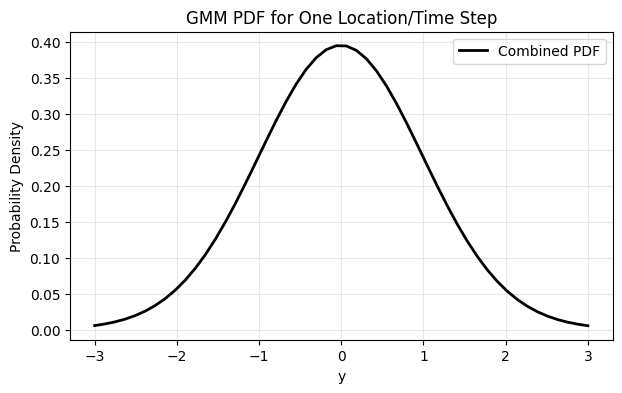

In [27]:
time_idx = -1
loc_idx = 0

mu = y_hat['discharge']['mu'][time_idx, loc_idx, :]
sigma = y_hat['discharge']['sigma'][time_idx, loc_idx, :]
pi = y_hat['discharge']['pi'][time_idx, loc_idx, :]

def gmm_pdf(x, mu, sigma, pi):
    """Compute combined GMM PDF over a range of x values."""
    one_over_sqrt_2pi = 1.0 / jnp.sqrt(2.0 * jnp.pi)
    x_unsqueezed = x[:, None]  # shape (n_x, n_components)
    exponent = -0.5 * jnp.square((x_unsqueezed - mu) / sigma)
    component_pdfs = one_over_sqrt_2pi * jnp.exp(exponent) / sigma
    weighted_pdf = jnp.sum(pi * component_pdfs, axis=-1)
    return weighted_pdf, component_pdfs

x = jnp.linspace(-3, 3, 50)
combined_pdf, component_pdfs = gmm_pdf(x, mu, sigma, pi)

# Plot each Gaussian component and the total
plt.figure(figsize=(7, 4))
plt.plot(x, combined_pdf, color='black', label='Combined PDF', linewidth=2)
plt.xlabel('y')
plt.ylabel('Probability Density')
plt.title('GMM PDF for One Location/Time Step')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [16]:
import jax.numpy as jnp
loss_name = cfg.step_kwargs.loss_name

if loss_name in ["nse", "spin_up_nse"]:
    # Expand the mask with a time dimension for broadcasting.
    node_mask = batch.node_mask[jnp.newaxis, :]
else:
    node_mask = batch.node_mask

node_mask.shape

(1, 7000)

In [17]:
from train.loss import get_loss_fn
loss_fn = get_loss_fn(cfg.step_kwargs.loss_name)

loss_fn

<function train.loss.spin_up_nse_loss(y: jax.Array, y_hat: jax.Array, mask: jax.Array)>

In [20]:
loss_name = cfg.step_kwargs.loss_name
target_weights = cfg.step_kwargs.target_weights

In [26]:
# Loop through the targets and calculate loss
losses = []
loss_fn = get_loss_fn(loss_name)
for target_name in y_hat.keys():
    y_target = batch.y[target_name][...,0]
    y_hat_target = y_hat[target_name][...,0]

    valid_mask = ~jnp.isnan(y_target) & node_mask
    masked_y = jnp.where(valid_mask, y_target, 0)

    if isinstance(y_hat_target, dict):
        masked_y_hat = {
            p_name: jnp.where(valid_mask, p_arr, 0)
            for p_name, p_arr in y_hat_target.items()
        }
    else:
        masked_y_hat = jnp.where(valid_mask, y_hat_target, 0)

    # Calculate masked loss, safeguard against NaN's, and apply target weights
    loss = loss_fn(masked_y, masked_y_hat, valid_mask)
    loss = jnp.nan_to_num(loss, 0) * target_weights[target_name]
    losses.append(loss)
    
loss = jnp.mean(jnp.stack(losses))
loss

Array(1.6836714, dtype=float32)

In [24]:
jnp.stack(losses)

Array([1.6836714], dtype=float32)

In [49]:
y_hat = y_pred
for target_name in y_hat.keys():
    break


y_target = batch.y[target_name][...,0]
y_hat_target = y_hat[target_name][...,0]

valid_mask = ~jnp.isnan(y_target) & node_mask
masked_y = jnp.where(valid_mask, y_target, 0)




(90, 7000)

In [50]:
masked_y.shape

(90, 7000)

In [46]:
jnp.isnan(y_target).shape

(90, 7000)

In [47]:
y_target.shape

(90, 7000)

In [38]:
jnp.isnan(y_target).shape

(90, 7000, 1)

In [ ]:
batch.static.shape

In [ ]:
jax_batch = batch.to_jax()
type(jax_batch.dynamic['era5'])

In [ ]:
from jax.tree import map as jt_map



type(jt_batch.dynamic['era5'])

In [ ]:
type(jt_batch)

In [ ]:
cfg.quiet = False
cfg.in_memory = True
mgr = data.shared_memory_manager(cfg, 'train')

In [ ]:
stores = mgr.init_shared_memory()

In [ ]:
dataset = data.LightBasinGraphDataset(cfg, stores)

In [ ]:
dataset.basin_x_ds

In [ ]:
import numpy as np
from multiprocessing import shared_memory
from pathlib import Path
import xarray as xr

def to_shared_array(name_prefix: str, arr: np.ndarray):
    """Create a shared memory array from numpy data."""
    shm = shared_memory.SharedMemory(create=True, size=arr.nbytes, name=name_prefix)
    shared = np.ndarray(arr.shape, dtype=arr.dtype, buffer=shm.buf)
    np.copyto(shared, arr)
    return {"name": shm.name, "shape": arr.shape, "dtype": str(arr.dtype)}


shared_zarr_stores = {}
for basin, ds in dataset.basin_x_ds.items():
    shared_zarr_stores[basin] = {}
    for var in ds.data_vars:
        arr = ds[var].values  # load into memory
        meta = to_shared_array(f"{basin}_{var}", arr)
        shared_zarr_stores[basin][var] = meta
    ds.close()


In [ ]:
def cleanup_shared_zarr_stores(shared_zarr_meta):
    for basin, vars_meta in shared_zarr_meta.items():
        for var, meta in vars_meta.items():
            shm = shared_memory.SharedMemory(name=meta["name"])
            shm.close()
            shm.unlink()

cleanup_shared_zarr_stores(shared_zarr_stores)

In [ ]:
shared_zarr_stores

In [ ]:
cfg.num_workers = 16
dataloader = data.LightBasinGraphDataLoader(cfg, dataset)

count = 0
for basin, date, batch in tqdm(dataloader):
    count += 1
    if count == 100:
        break

In [ ]:
df = pd.read_parquet(cfg.attributes_file)
df

In [ ]:
plt.hist(g['static_attr']['run_mm_syr'].values)

In [ ]:
cfg.quiet = False
cfg.in_memory = False
dataset = data.lightweight_basingraphdataset.LightBasinGraphDataset(cfg, 'train')

In [ ]:
cfg.quiet = False
cfg.in_memory = False
%memit dataset = data.BasinGraphDataset(cfg, 'train')
# dataloader = data.BasinGraphDataLoader(cfg, dataset)

In [ ]:
encoding = cfg.static_encoding.model_dump()
for col, categories in encoding['categorical'].items():
    break

In [ ]:
df['bitmask'] = np.random.randint(1, 16, df.shape[0])
df['bitmask'][df['bitmask']>4] = 0
df['bitmask']

In [ ]:
n = 0
((x_int // 2**n) % 2)

In [ ]:
((x_int // 2**n) % 2).any()

In [ ]:
# Discovery requires computing max value. This is a one-time cost.
x_int = df['bitmask'].astype(int)
max_val = x_int.max()
nbits = int(np.ceil(np.log2(max_val + 1))) if max_val > 0 else 0
nbits

# Check which bits are active across the dataset
# This part still requires computation to discover bits
active_bits = []
for n in range(nbits):
    if ((x_int // 2**n) % 2).any():
        active_bits.append(n)
prescribed_bits = active_bits
prescribed_bits

In [ ]:
len(dataset.basins)

In [ ]:
df[df.index.get_level_values('basin').isin(dataset.basins)]

In [ ]:
df = pd.read_parquet(cfg.attributes_file)
# df = df.droplevel("basin")

df

In [ ]:
for 

In [ ]:
del(dataloader)

In [ ]:
cfg.num_workers = 12
dataloader = data.BasinGraphDataLoader(cfg, dataset, worker_in_memory=False)

count = 0
for basin, date, batch in tqdm(dataloader):
    count +=1 
    if count == 100:
        break

In [ ]:
batch.graph_edges

In [ ]:
%reset -f out

In [ ]:
print_object_memory_usage(dataset)

In [ ]:
import sys
import numpy as np

def sizeof_fmt(num: float, suffix: str = "B") -> str:
    """Convert bytes to a human-readable string."""
    for unit in ["", "Ki", "Mi", "Gi", "Ti"]:
        if abs(num) < 1024.0:
            return f"{num:3.1f} {unit}{suffix}"
        num /= 1024.0
    return f"{num:.1f} Pi{suffix}"

def get_deep_size(obj, seen=None):
    """Recursively compute the memory footprint of an object and its contents."""
    size = sys.getsizeof(obj)
    if seen is None:
        seen = set()
    obj_id = id(obj)
    if obj_id in seen:
        return 0
    seen.add(obj_id)

    if isinstance(obj, dict):
        size += sum(get_deep_size(k, seen) + get_deep_size(v, seen) for k, v in obj.items())
    elif isinstance(obj, (list, tuple, set, frozenset)):
        size += sum(get_deep_size(i, seen) for i in obj)
    elif isinstance(obj, np.ndarray):
        size += obj.nbytes
    return size

def print_object_memory_usage(obj):
    """
    Print a breakdown of the memory usage for each attribute of an object.
    """
    attrs = getattr(obj, "__dict__", None)
    if attrs is None:
        print(f"{obj.__class__.__name__} has no __dict__ (probably a built-in or slotted object).")
        return

    print(f"\nMemory usage for instance of {obj.__class__.__name__}:")
    total = 0
    for name, value in attrs.items():
        size = get_deep_size(value)
        total += size
        print(f"  {name:25s}: {sizeof_fmt(size)} ({type(value).__name__})")
    print("-" * 60)
    print(f"  Total estimated size: {sizeof_fmt(total)}\n")




In [ ]:
cfg.quiet = False
cfg.in_memory = True
cfg.num_workers = 2
dataset = data.SharedBasinGraphDataset(cfg, 'train')
dataloader = data.SharedBasinGraphDataLoader(cfg, dataset)

In [ ]:
dataloader = data.SharedBasinGraphDataLoader(cfg, dataset)
for basin, date, batch in tqdm(dataloader):
    pass


In [ ]:
cfg.num_workers = 2
train_dataloader = data.BasinGraphDataLoader(cfg, train_dataset)

In [ ]:
import train
cfg.log = True
trainer = train.Trainer(cfg, train_dataloader)
trainer.start_training()

In [ ]:
train_dataloader = data.BasinGraphDataLoader(cfg, train_dataset)
for basin, date, batch in tqdm(train_dataloader):
    pass

In [ ]:
df.index.to_frame(index=False)

In [ ]:
import geopandas as gpd
proj_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/distributed")
metadata_dir = proj_dir / "metadata"
basins = gpd.read_file(metadata_dir / 'matchups.geojson').set_index("HYBAS_ID")
basins.index = basins.index.astype(str)
basins

In [ ]:
import evaluate
pred = evaluate.predict(trainer.model, dataloader, denormalize=False)

In [ ]:
pred

In [ ]:
x = pred.xs('2021-02-08', level='date')


x['pred']['discharge']

In [ ]:
x['pred']['discharge'].hist()

In [ ]:
basins_pred = basins.merge(x['pred']['discharge'], left_index=True, right_index=True)
basins_pred.plot('discharge')

In [ ]:
plt.scatter(x['obs']['discharge'], x['pred']['discharge'])
# plt.plot([0,500], [0,500], 'r--')